In [1]:
# インポート
import requests, zipfile
import io
import pandas as pd
import numpy as np

In [2]:

# 自動車価格データを取得
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data'
res = requests.get(url).content
# 取得したデータを DataFrame オブジェクトとして読み込み
auto = pd.read_csv(io.StringIO(res.decode('utf-8')), header=None)
# データの列にラベルを設定
auto.columns =['symboling','normalized-losses','make','fuel-type' ,'aspiration','num-of-doors', 
               'body-style','drive-wheels','engine-location','wheel-base','length','width','height',
               'curb-weight','engine-type','num-of-cylinders','engine-size','fuel-system','bore',
               'stroke','compression-ratio','horsepower','peak-rpm','city-mpg','highway-mpg','price']

In [3]:
print('自動車データの形式 :{}'.format(auto.shape))

自動車データの形式 :(205, 26)


In [4]:
auto.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [5]:
# それぞれのカラムに ? が何個あるかカウント
auto = auto[['price','horsepower','width','height']]
auto.isin(['?']).sum()

price         4
horsepower    2
width         0
height        0
dtype: int64

In [6]:
# ? を NaN に置換して、NaN がある行を削除
auto = auto.replace('?', np.nan).dropna()
print(' 自動車データの形式 :{}'.format(auto.shape))

 自動車データの形式 :(199, 4)


In [7]:
auto.corr()

,price,horsepower,width,height
price,1.000000,0.810533,0.753871,0.134990
horsepower,0.810533,1.000000,0.615315,-0.087407
width,0.753871,0.615315,1.000000,0.309223
height,0.134990,-0.087407,0.309223,1.000000


In [8]:
print(' データ型の確認（型変換前）\n{}'.format(auto.dtypes))

 データ型の確認（型変換前）
price             str
horsepower        str
width         float64
height        float64
dtype: object


In [9]:
auto = auto.assign(price=pd.to_numeric(auto.price))
auto = auto.assign(horsepower=pd.to_numeric(auto.horsepower))
print(' データ型の確認（型変換後）\n{}'.format(auto.dtypes))

 データ型の確認（型変換後）
price           int64
horsepower      int64
width         float64
height        float64
dtype: object


In [10]:
auto.corr()

,price,horsepower,width,height
price,1.000000,0.810533,0.753871,0.134990
horsepower,0.810533,1.000000,0.615315,-0.087407
width,0.753871,0.615315,1.000000,0.309223
height,0.134990,-0.087407,0.309223,1.000000


In [11]:
# データ分割（訓練データとテストデータ）のためのインポート
from sklearn.model_selection import train_test_split
# 重回帰のモデル構築のためのインポート
from sklearn.linear_model import LinearRegression
# 目的変数に price を指定、説明変数にそれ以外を指定
X = auto.drop('price', axis=1)
y = auto['price']
# 訓練データとテストデータに分ける
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)
# 重回帰クラスの初期化と学習
model = LinearRegression()
model.fit(X_train,y_train)
# 決定係数を表示
print(' 決定係数 (train):{:.3f}'.format(model.score(X_train,y_train)))
print(' 決定係数 (test):{:.3f}'.format(model.score(X_test,y_test)))
# 回帰係数と切片を表示
print('\n 回帰係数 \n{}'.format(pd.Series(model.coef_, index=X.columns)))
print(' 切片 : {:.3f}'.format(model.intercept_))

 決定係数 (train):0.733
 決定係数 (test):0.737

 回帰係数 
horsepower      81.651078
width         1829.174506
height         229.510077
dtype: float64
 切片 : -128409.046


In [12]:
#8-3

In [13]:
# データを取得
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
res = requests.get(url).content
# 取得したデータを DataFrame オブジェクトとして読み込み
adult = pd.read_csv(io.StringIO(res.decode('utf-8')), header=None)
# データの列にラベルを設定
adult.columns =['age','workclass','fnlwgt','education','education-num','marital-status',
                'occupation','relationship','race','sex','capital-gain',
                'capital-loss','hours-per-week',
                'native-country','flg-50K']

# データの形式と欠損数を出力
print(' データの形式 :{}'.format(adult.shape))
print(' 欠損の数 :{}'.format(adult.isnull().sum().sum()))
# データの先頭 5 行を出力
adult.head()

 データの形式 :(32561, 15)
 欠損の数 :0


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,flg-50K
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [14]:
adult.groupby('flg-50K').size()

flg-50K
<=50K    24720
>50K      7841
dtype: int64

In [15]:
# 「fin_flg」カラムを追加し、もし「flg-50K」カラムの値が「>50K」だったら 1、そうでなければ 0 をセットする
adult['fin_flg'] = adult['flg-50K'].map(lambda x: 1 if x ==' >50K' else 0)
adult.groupby('fin_flg').size()

fin_flg
0    24720
1     7841
dtype: int64

In [16]:
adult.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,flg-50K,fin_flg
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
# 説明変数と目的変数の設定
X = adult[['age','fnlwgt','education-num','capital-gain','capital-loss']]
y = adult['fin_flg']
# 訓練データとテストデータに分ける
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)
# ロジスティック回帰クラスの初期化と学習
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
print(' 正解率 (train):{:.3f}'.format(model.score(X_train, y_train)))
print(' 正解率 (test):{:.3f}'.format(model.score(X_test, y_test)))

 正解率 (train):0.811
 正解率 (test):0.811


In [18]:
model.coef_

array([[3.91581249e-02, 2.42525056e-07, 3.26385231e-01, 3.10435980e-04,
        7.03036962e-04]])

In [19]:
np.exp(model.coef_)

array([[1.03993491, 1.00000024, 1.38594918, 1.00031048, 1.00070328]])

In [20]:
# 標準化のためのクラスをインポート
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# X と y を設定
X = adult[['age','fnlwgt','education-num','capital-gain','capital-loss']]
y = adult['fin_flg']
# 訓練データとテストデータに分ける
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)
# 標準化処理
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)
# ロジスティック回帰クラスの初期化と学習
model = LogisticRegression()
model.fit(X_train_std,y_train)
# 正解率の表示
print(' 正解率 (train):{:.3f}'.format(model.score(X_train_std, y_train)))
print(' 正解率 (test):{:.3f}'.format(model.score(X_test_std, y_test)))

 正解率 (train):0.811
 正解率 (test):0.810


In [21]:
#8-4

In [38]:
# 自動車価格データを取得
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data'
res = requests.get(url).content
# 取得したデータを DataFrame オブジェクトとして読み込み
auto = pd.read_csv(io.StringIO(res.decode('utf-8')), header=None)
# データの列にラベルを設定
auto.columns =['symboling','normalized-losses','make','fuel-type' ,'aspiration','num-of-doors', 
               'body-style','drive-wheels','engine-location','wheel-base','length','width','height',
               'curb-weight','engine-type','num-of-cylinders','engine-size','fuel-system','bore',
               'stroke','compression-ratio','horsepower','peak-rpm','city-mpg','highway-mpg','price']

In [39]:
# それぞれのカラムに ? が何個あるかカウント
auto = auto[['price','horsepower','width','height']]
auto.isin(['?']).sum()

price         4
horsepower    2
width         0
height        0
dtype: int64

In [40]:
# ? を NaN に置換して、NaN がある行を削除
auto = auto.replace('?', np.nan).dropna()
print(' 自動車データの形式 :{}'.format(auto.shape))

 自動車データの形式 :(199, 4)


In [50]:
auto = auto.assign(price=pd.to_numeric(auto.price))
auto = auto.assign(horsepower=pd.to_numeric(auto.horsepower))
print(' データ型の確認（型変換後）\n{}'.format(auto.dtypes))

 データ型の確認（型変換後）
price           int64
horsepower      int64
width         float64
height        float64
dtype: object


In [51]:
auto.head()

,price,horsepower,width,height
0,13495,111,64.1,48.8
1,16500,111,64.1,48.8
2,16500,154,65.5,52.4
3,13950,102,66.2,54.3
4,17450,115,66.4,54.3


In [52]:
# リッジ回帰用のクラス
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
# 訓練データとテストデータに分割
X = auto.drop('price', axis=1)
y = auto['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)
# モデルの構築と評価
linear = LinearRegression()
ridge = Ridge(random_state=0)
for model in [linear, ridge]:
    model.fit(X_train,y_train)
    print('{}(train):{:.6f}'.format(model.__class__.__name__ , model.score(X_train,y_train)))
    print('{}(test):{:.6f}'.format(model.__class__.__name__ , model.score(X_test,y_test)))

LinearRegression(train):0.733358
LinearRegression(test):0.737069
Ridge(train):0.733355
Ridge(test):0.737768


In [53]:
#8-5

In [54]:
# データを取得
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data'
res = requests.get(url).content
# 取得したデータを DataFrame オブジェクトとして読み込み
mushroom = pd.read_csv(io.StringIO(res.decode('utf-8')), header=None)
# データの列にラベルを設定
mushroom.columns =['classes','cap_shape','cap_surface','cap_color','odor','bruises',
'gill_attachment','gill_spacing','gill_size','gill_color','stalk_shape',
'stalk_root','stalk_surface_above_ring','stalk_surface_below_ring',
'stalk_color_above_ring','stalk_color_below_ring','veil_type','veil_color',
'ring_number','ring_type','spore_print_color','population','habitat']
# 先頭 5 行を表示
mushroom.head()

,classes,cap_shape,cap_surface,cap_color,odor,bruises,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [55]:
print(' データの形式 :{}'.format(mushroom.shape))
print(' 欠損の数 :{}'.format(mushroom.isnull().sum().sum()))

 データの形式 :(8124, 23)
 欠損の数 :0


In [56]:
mushroom_dummy = pd.get_dummies(mushroom[['gill_color','gill_attachment','odor','cap_color']])
mushroom_dummy.head()

,gill_color_b,gill_color_e,gill_color_g,gill_color_h,gill_color_k,gill_color_n,gill_color_o,gill_color_p,gill_color_r,gill_color_u,...,cap_color_b,cap_color_c,cap_color_e,cap_color_g,cap_color_n,cap_color_p,cap_color_r,cap_color_u,cap_color_w,cap_color_y
0,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [57]:
# 目的変数もフラグ化（0/1 化）する
mushroom_dummy['flg'] = mushroom['classes'].map(lambda x: 1 if x =='p' else 0)

In [58]:
mushroom_dummy

,gill_color_b,gill_color_e,gill_color_g,gill_color_h,gill_color_k,gill_color_n,gill_color_o,gill_color_p,gill_color_r,gill_color_u,...,cap_color_c,cap_color_e,cap_color_g,cap_color_n,cap_color_p,cap_color_r,cap_color_u,cap_color_w,cap_color_y,flg
0,False,False,False,False,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,1
1,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,0
2,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0
3,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,1
4,False,False,False,False,True,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,0
8120,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,0
8121,False,False,False,False,False,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,0
8122,True,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,1


In [59]:
mushroom_dummy.groupby(['cap_color_c', 'flg'])['flg'].count().unstack()

flg,0,1
cap_color_c,,
False,4176,3904
True,32,12


In [60]:
mushroom_dummy.groupby(['gill_color_b', 'flg'])['flg'].count().unstack()

flg,0,1
gill_color_b,,
False,4208.0,2188.0
True,NaN,1728.0


In [61]:
def calc_entropy(p):
    return - (p * np.log2(p) + (1 - p) * np.log2(1 - p) )

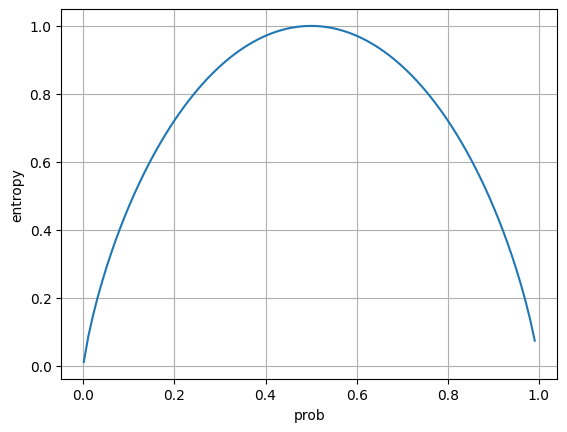

In [63]:
import matplotlib.pyplot as plt
# p の値を 0.001 から 0.999 まで 0.01 刻みで動かす
p = np.arange(0.001, 0.999, 0.01)
# グラフ化
plt.plot(p, calc_entropy(p))
plt.xlabel('prob')
plt.ylabel('entropy')
plt.grid(True)

In [64]:
mushroom_dummy.groupby('flg')['flg'].count()

flg
0    4208
1    3916
Name: flg, dtype: int64

In [65]:
entropy_init = - (0.518 * np.log2(0.518) + 0.482 * np.log2(0.482))
print(' 毒キノコデータのエントロピーの初期値 : {:.3f}'.format(entropy_init))

 毒キノコデータのエントロピーの初期値 : 0.999


In [66]:
mushroom_dummy.groupby(['cap_color_c', 'flg'])['flg'].count().unstack()

flg,0,1
cap_color_c,,
False,4176,3904
True,32,12


In [67]:
# cap_color が c でない場合のエントロピー
p1 = 4176 / (4176 + 3904)
p2 = 1 - p1
entropy_c0 = -(p1*np.log2(p1)+p2*np.log2(p2))
print('entropy_c0: {:.3f}'.format(entropy_c0))

entropy_c0: 0.999


In [68]:
# cap_color が c である場合のエントロピー
p1 = 32/(32+12)
p2 = 1 - p1
entropy_c1 = -(p1*np.log2(p1)+p2*np.log2(p2))
print('entropy_c1: {:.3f}'.format(entropy_c1))

entropy_c1: 0.845


In [69]:
entropy_after = (4176+3904)/8124*entropy_c0 + (32+12)/8124*entropy_c1
print(' データ分割後の平均エントロピー : {:.3f}'.format(entropy_after))

 データ分割後の平均エントロピー : 0.998


In [70]:
print(' 変数 cap_color の分割によって得られる情報利得 : {:.3f}'.format(entropy_init - entropy_after))

 変数 cap_color の分割によって得られる情報利得 : 0.001


In [71]:
mushroom_dummy.groupby(['gill_color_b', 'flg'])['flg'].count().unstack()

flg,0,1
gill_color_b,,
False,4208.0,2188.0
True,NaN,1728.0


In [72]:
# gill_color が b でない場合のエントロピー
p1 = 4208/(4208+2188)
p2 = 1 - p1
entropy_b0 = - (p1*np.log2(p1) + p2*np.log2(p2))
# gill_color が b である場合のエントロピー
p1 = 0/(0+1728)
p2 = 1 - p1
entropy_b1 = - (p2*np.log2(p2))
entropy_after = (4208+2188)/8124*entropy_b0 + (0+1728)/8124*entropy_b1
print(' 変数 gill_color の分割によって得られる情報利得 : {:.3f}'.format(entropy_init - entropy_after))

 変数 gill_color の分割によって得られる情報利得 : 0.269


In [73]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
# データ分割
X = mushroom_dummy.drop('flg', axis=1)
y = mushroom_dummy['flg']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
# 決定木クラスの初期化と学習
model = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)
model.fit(X_train,y_train)
print(' 正解率 (train):{:.3f}'.format(model.score(X_train, y_train)))
print(' 正解率 (test):{:.3f}'.format(model.score(X_test, y_test)))

 正解率 (train):0.883
 正解率 (test):0.894


In [ ]:
#8-6

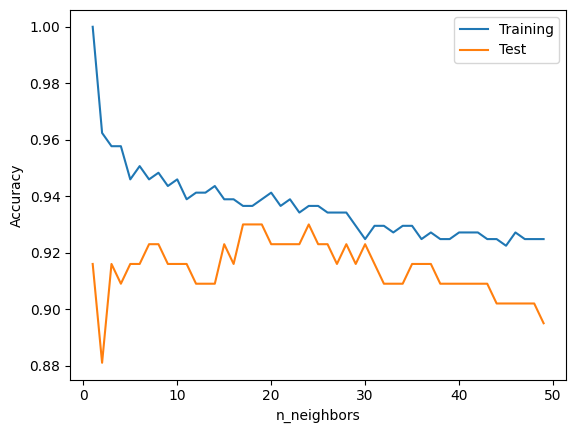

In [81]:
# データやモデルを構築するためのライブラリ等のインポート
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
# データセットの読み込み
cancer = load_breast_cancer()
# 訓練データとテストデータに分ける
# stratify は層化別抽出
X_train, X_test, y_train, y_test = train_test_split(
cancer.data, cancer.target, stratify = cancer.target, random_state=0)
# グラフ描画用のリストを用意
training_accuracy = []
test_accuracy =[]
# 学習
for n_neighbors in range(1,50):
    model = KNeighborsClassifier(n_neighbors=n_neighbors)
    model.fit(X_train,y_train)
    training_accuracy.append(model.score(X_train, y_train))
    test_accuracy.append(model.score(X_test, y_test))
# グラフを描画
plt.plot(range(1,50), training_accuracy, label='Training')
plt.plot(range(1,50), test_accuracy, label='Test')
plt.ylabel('Accuracy')
plt.xlabel('n_neighbors')
plt.legend()

In [ ]:
maxIndex = [i for i, x in enumerate(test_accuracy) if x == max(test_accuracy)]
print(maxIndex)

[16, 17, 18, 23]
